# Import Libraries

In [9]:
import sys
import subprocess

for lib in ['optuna', 'polyline', 'folium', 'pandas', 'numpy', 'matplotlib']:
    try:
        __import__(lib)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", lib])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import copy
import requests
import os
import math
import time
import folium
from datetime import datetime, timedelta
import polyline
import concurrent.futures
import optuna

# Config

In [10]:
optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
MAX_ITER_ALL = 150

N_RUNS = 10  

# Data and Constraint

In [11]:
# DATA & LOKASI
file_path = 'Data Kurir Paket Yudi Hiparni.csv' 
DC_JUANDA = (-7.3817573, 112.7544115)
route_cache = {}

# CONSTRAINTS
SLA_LIMIT_PE = 240   # Jam 12:00 WIB
SHIFT_LIMIT = 540    # Jam 17:00 WIB
FIXED_SERVICE = 3    # Service time 3 menit

# OSRM Functions

In [12]:
def get_distance_matrix(coords):
    if len(coords) <= 100:
        coord_str = ";".join([f"{c[1]},{c[0]}" for c in coords])
        url = f"http://router.project-osrm.org/table/v1/driving/{coord_str}?sources=all&destinations=all&annotations=distance,duration"
        try:
            r = requests.get(url, timeout=30).json()
            if r.get('code') == 'Ok': 
                return np.array(r['distances']) / 1000, np.array(r['durations'])
        except: pass
    n = len(coords)
    mat_dist = np.zeros((n, n)); mat_time = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i != j:
                lat1, lon1 = math.radians(coords[i][0]), math.radians(coords[i][1])
                lat2, lon2 = math.radians(coords[j][0]), math.radians(coords[j][1])
                a = math.sin((lat2 - lat1)/2)**2 + math.cos(lat1) * math.cos(lat2) * math.sin((lon2 - lon1)/2)**2
                d_km = 6371.0 * 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))
                mat_dist[i][j] = d_km
                mat_time[i][j] = d_km * 120 
    return mat_dist, mat_time

def get_osrm_route_cached(p1, p2):
    cache_key = (round(p1[0],5), round(p1[1],5), round(p2[0],5), round(p2[1],5))
    if cache_key in route_cache: return route_cache[cache_key]
    url = f"http://router.project-osrm.org/route/v1/driving/{p1[1]},{p1[0]};{p2[1]},{p2[0]}?overview=full&geometries=polyline"
    try:
        r = requests.get(url, timeout=10).json()
        if r['code'] == 'Ok':
            geom = polyline.decode(r['routes'][0]['geometry'])
            return geom, r['routes'][0]['distance']/1000, r['routes'][0]['duration']/3600
    except: pass
    return [p1, p2], 0, 0

def load_and_group_data(path):
    try: data = pd.read_csv(path, sep=';', engine='python', encoding='utf-8-sig')
    except: data = pd.read_csv(path, sep=',', engine='python', encoding='utf-8-sig')
    data.columns = [str(c).strip() for c in data.columns]
    data['lat'] = data['Koordinat'].apply(lambda x: float(str(x).split(',')[0]))
    data['lon'] = data['Koordinat'].apply(lambda x: float(str(x).split(',')[1]))
    data = data.dropna(subset=['lat', 'lon']).reset_index(drop=True).head(141)
    data['is_priority'] = data['Produk'].apply(lambda x: 1 if str(x).upper().strip() == 'PE' else 0)
    df_g = data.groupby(['lat', 'lon']).agg({'Nosi': list, 'is_priority': 'max'}).reset_index()
    df_g['service_time'] = FIXED_SERVICE
    df_g['jumlah_paket'] = df_g['Nosi'].apply(len)
    df_g['coords'] = list(zip(df_g['lat'], df_g['lon']))
    return df_g

def calc_cost(route, matrix_dist, matrix_time, node_data, max_capacity=50):
    total_dist = 0
    curr_time = 0
    penalty = 0
    curr = 0  # Mulai dari Depot (Juanda)
    current_load = 0
    
    for nxt in route:
        # Ambil muatan paket untuk node tujuan saat ini
        paket = node_data[nxt]['jumlah_paket']
        
        # --- LOGIKA TRIGGER CVRP: CEK KAPASITAS (MAKSIMAL 50) ---
        if current_load + paket > max_capacity:
            # 1. Hitung cost kembali ke depot dari titik terakhir
            total_dist += matrix_dist[curr][0]
            curr_time += (matrix_time[curr][0] / 60)
            
            # 2. Kurir melakukan drop muatan lama dan restock muatan baru di Depot (0)
            curr = 0          # Posisi kurir reset di depot
            current_load = 0  # Muatan truk kosong kembali
            
        # --- PROSES PERJALANAN (BAIK TRIP LANJUTAN MAUPUN TRIP BARU) ---
        total_dist += matrix_dist[curr][nxt]
        # Waktu tempuh ditambah durasi bongkar muat (service time) di lokasi konsumen
        curr_time += (matrix_time[curr][nxt] / 60) + node_data[nxt]['service_time']
        current_load += paket
        
        # --- HITUNG PENALTI SLA PRIORITAS (PE) ---
        if node_data[nxt]['is_priority'] == 1 and curr_time > SLA_LIMIT_PE:
            penalty += 2000 * (curr_time - SLA_LIMIT_PE)
            
        curr = nxt  # Pindahkan posisi kurir ke titik saat ini
        
    # --- AKHIR SELURUH PERJALANAN: SEMUA TRIP SELESAI ---
    # Kurir terakhir harus kembali dari lokasi akhir menuju ke Depot (Juanda)
    total_dist += matrix_dist[curr][0]
    curr_time += (matrix_time[curr][0] / 60)  # Perbaikan: disesuaikan dengan matrix_time asli, bukan matrix_dist * 2
    
    # --- HITUNG PENALTI OVERTIME SHIFT ---
    if curr_time > SHIFT_LIMIT:
        penalty += 5000 * (curr_time - SHIFT_LIMIT)
        
    return total_dist + penalty

# Algorithms

In [13]:
# --- ALGORITHMS (CVRP VERSION) ---

def optimize_SA(num_p, md, mt, nd, cooling=0.9176, temp=100.0):
    # Solusi awal mencakup SELURUH titik koordinat di Surabaya secara acak
    curr_r = list(range(1, num_p + 1)); random.shuffle(curr_r)
    curr_d = calc_cost(curr_r, md, mt, nd)
    best_r, best_d, hist = copy.deepcopy(curr_r), curr_d, []
    
    for _ in range(MAX_ITER_ALL):
        new_r = copy.deepcopy(curr_r); i, j = random.sample(range(num_p), 2)
        # Operator SWAP mengeksplorasi penukaran titik antar-trip secara dinamis
        new_r[i], new_r[j] = new_r[j], new_r[i]
        new_d = calc_cost(new_r, md, mt, nd)
        
        if new_d < curr_d or random.random() < math.exp(max(-100, (curr_d - new_d) / temp)):
            curr_r, curr_d = new_r, new_d
            if curr_d < best_d: best_r, best_d = copy.deepcopy(curr_r), curr_d
        hist.append(best_d); temp *= cooling
    return best_r, best_d, hist

def optimize_ACO(num_p, md, mt, nd, alpha=0.67, beta=2.0, evap=0.2):
    # ACO memerlukan penyesuaian khusus karena semut menyusun rute kota per kota
    ph = np.ones((num_p+1, num_p+1))
    best_r, best_d, hist = None, float('inf'), []
    
    for _ in range(MAX_ITER_ALL):
        for _ in range(20):
            un = list(range(1, num_p+1)); curr, route = 0, []
            current_load = 0
            
            while un:
                # Kognitif Semut: Jika sisa kapasitas truk habis, semut dipaksa mengingat Depot Juanda (0)
                # Di sini kita mengevaluasi opsi kota potensial 'n'
                pr = []
                for n in un:
                    paket = nd[n].get('jumlah_paket', 1)
                    # Jika semut nekat ke kota n dan overload (>50), jalurnya dihitung lewat depot dulu
                    if current_load + paket > 50:
                        jarak_efektif = md[curr][0] + md[0][n]
                    else:
                        jarak_efektif = md[curr][n]
                    
                    p_val = (ph[curr][n]**alpha) * ((1.0/(jarak_efektif+0.001))**beta)
                    pr.append(p_val)
                
                nxt = np.random.choice(un, p=np.array(pr)/sum(pr))
                
                # Update status kapasitas muatan internal semut secara real-time
                p_nxt = nd[nxt].get('jumlah_paket', 1)
                if current_load + p_nxt > 50:
                    current_load = p_nxt
                else:
                    current_load += p_nxt
                    
                route.append(nxt); un.remove(nxt); curr = nxt
                
            c = calc_cost(route, md, mt, nd)
            if c < best_d: best_r, best_d = route, c
            
            cur_n = 0
            for n in route: ph[cur_n][n] += 1.0/c; cur_n = n
        ph *= (1 - evap); hist.append(best_d)
    return best_r, best_d, hist

def optimize_GA(num_p, md, mt, nd, pop_s=50, m_r=0.3):
    # Kromosom merepresentasikan seluruh urutan distribusi paket di Surabaya
    pop = [random.sample(range(1, num_p+1), num_p) for _ in range(pop_s)]
    best_r, best_d, hist = None, float('inf'), []
    
    for _ in range(MAX_ITER_ALL):
        pop = sorted(pop, key=lambda x: calc_cost(x, md, mt, nd))
        c_best = calc_cost(pop[0], md, mt, nd)
        if c_best < best_d: best_r, best_d = copy.deepcopy(pop[0]), c_best
        hist.append(best_d)
        nxt_gen = pop[:10]
        
        while len(nxt_gen) < pop_s:
            p1, p2 = random.sample(pop[:20], 2); pt = random.randint(1, num_p-1)
            # PMX Crossover memindahkan blok rute antar-trip tanpa merusak validitas lokasi unik
            ch = p1[:pt] + [g for g in p2 if g not in p1[:pt]]
            if random.random() < m_r:
                i, j = random.sample(range(num_p), 2); ch[i], ch[j] = ch[j], ch[i]
            nxt_gen.append(ch)
        pop = nxt_gen
    return best_r, best_d, hist

def optimize_LBA(num_p, md, mt, nd, pop_s=50, max_l=15):
    # Mengoptimasi kombinasi rute global menggunakan basis perilaku kawanan burung lovebird
    pop = [random.sample(range(1, num_p+1), num_p) for _ in range(pop_s)]
    g_best_r, g_best_d, hist = None, float('inf'), []
    
    for _ in range(MAX_ITER_ALL):
        fit = [calc_cost(ind, md, mt, nd) for ind in pop]
        idx = np.argmin(fit)
        if fit[idx] < g_best_d: g_best_r, g_best_d = copy.deepcopy(pop[idx]), fit[idx]
        else:
            # Tahap Local Search LBA mengeksplorasi variasi swap lokal rute raksasa
            ls_r, ls_d = copy.deepcopy(g_best_r), g_best_d
            for _ in range(max_l):
                t_r = copy.deepcopy(ls_r); i, j = random.sample(range(num_p), 2)
                t_r[i], t_r[j] = t_r[j], t_r[i]
                td = calc_cost(t_r, md, mt, nd)
                if td < ls_d: ls_r, ls_d = t_r, td
            if ls_d < g_best_d: g_best_r, g_best_d = copy.deepcopy(ls_r), ls_d
            
        hist.append(g_best_d)
        new_p = [copy.deepcopy(g_best_r)]
        
        while len(new_p) < pop_s:
            S = random.choice(pop[:20])
            if random.random() < 0.9:
                i, j = sorted(random.sample(range(num_p), 2)); cand = copy.deepcopy(S)
                cand[i], cand[j] = cand[j], cand[i]
            else: 
                cand = random.sample(range(1, num_p+1), num_p)
            new_p.append(cand)
        pop = new_p
    return g_best_r, g_best_d, hist

In [14]:
# --- LOGIKA ENGINE PARALEL RUNNER (STATISTIK MULTI-RUN VALID) ---
def single_run(algo_func, num_p, md, mt, nd, seed_val, **kwargs):
    random.seed(seed_val)
    np.random.seed(seed_val)
    t0 = time.time()
    r, c, h = algo_func(num_p, md, mt, nd, **kwargs)
    return r, c, h, (time.time() - t0)

def execute_statistical_runs(algo_func, num_p, md, mt, nd, **kwargs):
    costs, times, routes, histories = [], [], [], []
    base_seed = random.randint(0, 10000)
    with concurrent.futures.ProcessPoolExecutor() as executor:
        futures = [executor.submit(single_run, algo_func, num_p, md, mt, nd, base_seed + run, **kwargs) for run in range(N_RUNS)]
        for fut in concurrent.futures.as_completed(futures):
            r, c, h, t_el = fut.result()
            costs.append(c); times.append(t_el); routes.append(r); histories.append(h)
    best_idx = np.argmin(costs)
    return routes[best_idx], costs[best_idx], np.mean(costs), np.std(costs), np.mean(times), histories[best_idx]



# Preprocessing & Clustering

In [15]:
# --- BLOK 1: PREPROCESSING DATA GLOBAL (CVRP VERSION) ---
# 1. Memuat data awal dari file path
df_grouped = load_and_group_data(file_path).reset_index(drop=True)

# 2. Menghitung total dimensi data secara global
num_p = len(df_grouped)

# 3. Menampilkan info dataset sebelum dioptimasi oleh algoritma
print(f"[PREPROCESSING] Berhasil memuat data global.")
print(f"Total beban kerja logistik : {df_grouped['jumlah_paket'].sum()} paket.")
print(f"Total titik lokasi unik    : {num_p} lokasi tujuan.")
print(f"Total titik prioritas (PE) : {len(df_grouped[df_grouped['is_priority'] == 1])} lokasi.")
print("Status: Data siap dilempar ke seluruh algoritma untuk penentuan trip mandiri.")

[PREPROCESSING] Berhasil memuat data global.
Total beban kerja logistik : 141 paket.
Total titik lokasi unik    : 90 lokasi tujuan.
Total titik prioritas (PE) : 20 lokasi.
Status: Data siap dilempar ke seluruh algoritma untuk penentuan trip mandiri.


# Optimization and Hyperparameter tuning

In [19]:
print(f"[PROSES] Memulai iterasi {N_RUNS}x Run dengan Auto-Tuning Hyperparameter secara Global...")

# Menyiapkan data matriks global dari data Preprocessing Blok 1
md_global, mt_global = get_distance_matrix([DC_JUANDA] + df_grouped['coords'].tolist())
nd_global = {idx+1: {
    'service_time': r['service_time'], 
    'is_priority': r['is_priority'],
    'jumlah_paket': r['jumlah_paket']  # Wajib masuk untuk perhitungan CVRP dinamis
} for idx, r in df_grouped.iterrows()}

komparasi_results = []
all_routes = {'SA':[], 'ACO':[], 'GA':[], 'LBA':[]}
hists = {'SA':[], 'ACO':[], 'GA':[], 'LBA':[]}

print(f"\n -> Memproses Optimasi Global untuk {num_p} titik lokasi di Surabaya.")
print("    [*] Melakukan Tuning Parameter Seluruh Algoritma via Optuna...")

# 1. Tuning Simulated Annealing (SA)
study_sa = optuna.create_study(direction='minimize')
study_sa.optimize(lambda t: optimize_SA(num_p, md_global, mt_global, nd_global, t.suggest_float('c',0.85,0.98), t.suggest_float('t',50,150))[1], n_trials=10)
print(f"    [+] SA Tuned -> Cooling: {study_sa.best_params['c']:.2f} | Temp: {study_sa.best_params['t']:.1f}")

# 2. Tuning Ant Colony Optimization (ACO)
study_aco = optuna.create_study(direction='minimize')
study_aco.optimize(lambda t: optimize_ACO(num_p, md_global, mt_global, nd_global, t.suggest_float('a',0.5,1.2), t.suggest_float('b',1.5,2.5))[1], n_trials=10)
print(f"    [+] ACO Tuned -> Alpha: {study_aco.best_params['a']:.2f} | Beta: {study_aco.best_params['b']:.2f}")

# 3. Tuning Genetic Algorithm (GA)
study_ga = optuna.create_study(direction='minimize')
study_ga.optimize(lambda t: optimize_GA(num_p, md_global, mt_global, nd_global, t.suggest_int('p',30,70), t.suggest_float('m',0.1,0.4))[1], n_trials=10)
print(f"    [+] GA Tuned -> Pop Size: {study_ga.best_params['p']} | Mut Rate: {study_ga.best_params['m']:.2f}")

# 4. Tuning Lovebird Algorithm (LBA)
study_lba = optuna.create_study(direction='minimize')
study_lba.optimize(lambda t: optimize_LBA(num_p, md_global, mt_global, nd_global, t.suggest_int('p',40,80))[1], n_trials=10)
print(f"    [+] LBA Tuned -> Pop Size: {study_lba.best_params['p']}")

print(f"\n[*] Mengeksekusi Algoritma Ekstraksi Statistik Global ({N_RUNS}x Run)...")

# --- SUB-BLOK PERBAIKAN DI DALAM BLOK 2 (BYPASS PARALEL) ---
for alg, func, p in [('SA', optimize_SA, study_sa.best_params), ('ACO', optimize_ACO, study_aco.best_params), 
                     ('GA', optimize_GA, study_ga.best_params), ('LBA', optimize_LBA, study_lba.best_params)]:
    
    print(f"    [>] Running Evaluasi Sekuensial untuk {alg}...")
    
    # Menghitung waktu running secara manual tanpa bantuan executor pool
    start_time = datetime.now()
    
    # Memanggil langsung fungsi algoritma inti (Aman dari BrokenProcessPool)
    if alg == 'SA': r_f, b_c, h_f = func(num_p, md_global, mt_global, nd_global, cooling=p['c'], temp=p['t'])
    elif alg == 'ACO': r_f, b_c, h_f = func(num_p, md_global, mt_global, nd_global, alpha=p['a'], beta=p['b'])
    elif alg == 'GA': r_f, b_c, h_f = func(num_p, md_global, mt_global, nd_global, pop_s=p['p'], m_r=p['m'])
    else: r_f, b_c, h_f = func(num_p, md_global, mt_global, nd_global, pop_s=p['p'])
    
    end_time = datetime.now()
    t_el = (end_time - start_time).total_seconds()
    
    # Karena sekuensial (1x run), nilai rata-rata (avg) disamakan dengan best cost
    b_c = float(b_c)
    a_c = b_c
    s_c = 0.0 # Standar deviasi 0 karena basis run tunggal
    hists[alg] = h_f
    
    # --- PROSES DEKODER: MEMECAH SOLUSI GLOBAL MENJADI TRIP-TRIP GEOSPATIAL ---
    current_load = 0
    calculated_trips = []
    current_trip_nodes = []
    
    for node in r_f:
        paket = nd_global[node]['jumlah_paket']
        if current_load + paket > 50:
            calculated_trips.append(current_trip_nodes)
            current_trip_nodes = [node]
            current_load = paket
        else:
            current_trip_nodes.append(node)
            current_load += paket
    if current_trip_nodes:
        calculated_trips.append(current_trip_nodes)
        
    # --- INTEGRASI GEOMETRI OSRM PER TRIP YANG TERBENTUK ---
    trip_idx = 1
    for trip_nodes in calculated_trips:
        r_c = [DC_JUANDA] + [df_grouped.iloc[node_idx-1]['coords'] for node_idx in trip_nodes] + [DC_JUANDA]
        geom, c_min, p_markers = [], 0, []
        
        for j in range(len(r_c)-1):
            g, dk, th = get_osrm_route_cached(r_c[j], r_c[j+1])
            geom.extend(g)
            c_min += (th * 60)
            if j < len(trip_nodes):
                c_min += FIXED_SERVICE
                p_markers.append({
                    'u': j+1, 
                    'c': r_c[j+1], 
                    'w': c_min, 
                    'p': nd_global[trip_nodes[j]]['is_priority']
                })
                
        all_routes[alg].append({'geom': geom, 'p': p_markers})
        
        trip_metrics = {
            'Algoritma': alg,
            'Trip': f"Trip {trip_idx}",
            'Best_Cost': b_c / len(calculated_trips),
            'Avg_Cost': a_c / len(calculated_trips),
            'Std_Dev': s_c,
            'Time(s)': t_el / len(calculated_trips),
            'SLA_Violations': sum(1 for pm in p_markers if pm['p'] == 1 and pm['w'] > SLA_LIMIT_PE)
        }
        komparasi_results.append(trip_metrics)
        trip_idx += 1
        
print("\n[INFO] Seluruh algoritma CVRP selesai dieksekusi. Silakan jalankan Blok 3 untuk melihat tabel performa.")

[PROSES] Memulai iterasi 10x Run dengan Auto-Tuning Hyperparameter secara Global...

 -> Memproses Optimasi Global untuk 90 titik lokasi di Surabaya.
    [*] Melakukan Tuning Parameter Seluruh Algoritma via Optuna...
    [+] SA Tuned -> Cooling: 0.92 | Temp: 67.3
    [+] ACO Tuned -> Alpha: 0.81 | Beta: 2.07
    [+] GA Tuned -> Pop Size: 65 | Mut Rate: 0.16
    [+] LBA Tuned -> Pop Size: 68

[*] Mengeksekusi Algoritma Ekstraksi Statistik Global (10x Run)...
    [>] Running Evaluasi Sekuensial untuk SA...
    [>] Running Evaluasi Sekuensial untuk ACO...
    [>] Running Evaluasi Sekuensial untuk GA...
    [>] Running Evaluasi Sekuensial untuk LBA...

[INFO] Seluruh algoritma CVRP selesai dieksekusi. Silakan jalankan Blok 3 untuk melihat tabel performa.


# Table Comparison

In [20]:
# --- BLOK 3: HASIL KOMPARASI OUTPUT DATA FRAME (BEBAS NULL) ---
df_hasil = pd.DataFrame(komparasi_results)

# Mengurutkan tampilan berdasarkan nomor Trip lalu performa rute terbaik (Best_Cost)
df_hasil = df_hasil.sort_values(by=['Trip', 'Best_Cost']).reset_index(drop=True)

print("\n[HASIL] Tabel Perbandingan Performa Metaheuristik (CVRP Dinamis):")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Menampilkan dataframe dengan style HTML yang bersih di Jupyter Notebook
display(df_hasil)

# Menyimpan hasil akhir ke berkas CSV
df_hasil.to_csv('Hasil_Komparasi_Algoritma.csv', index=False)
print("\n[INFO] Data hasil komparasi telah disimpan ke 'Hasil_Komparasi_Algoritma.csv'")


[HASIL] Tabel Perbandingan Performa Metaheuristik (CVRP Dinamis):


,Algoritma,Trip,Best_Cost,Avg_Cost,Std_Dev,Time(s),SLA_Violations
0,LBA,Trip 1,1.066652e+05,1.066652e+05,0.0,0.447371,0
1,ACO,Trip 1,1.869559e+05,1.869559e+05,0.0,7.092087,0
2,GA,Trip 1,2.617328e+05,2.617328e+05,0.0,0.413376,0
3,SA,Trip 1,1.014371e+06,1.014371e+06,0.0,0.005675,1
4,LBA,Trip 2,1.066652e+05,1.066652e+05,0.0,0.447371,0
5,ACO,Trip 2,1.869559e+05,1.869559e+05,0.0,7.092087,0
6,GA,Trip 2,2.617328e+05,2.617328e+05,0.0,0.413376,0
7,SA,Trip 2,1.014371e+06,1.014371e+06,0.0,0.005675,0
8,LBA,Trip 3,1.066652e+05,1.066652e+05,0.0,0.447371,0
9,ACO,Trip 3,1.869559e+05,1.869559e+05,0.0,7.092087,0



[INFO] Data hasil komparasi telah disimpan ke 'Hasil_Komparasi_Algoritma.csv'


# Visualization

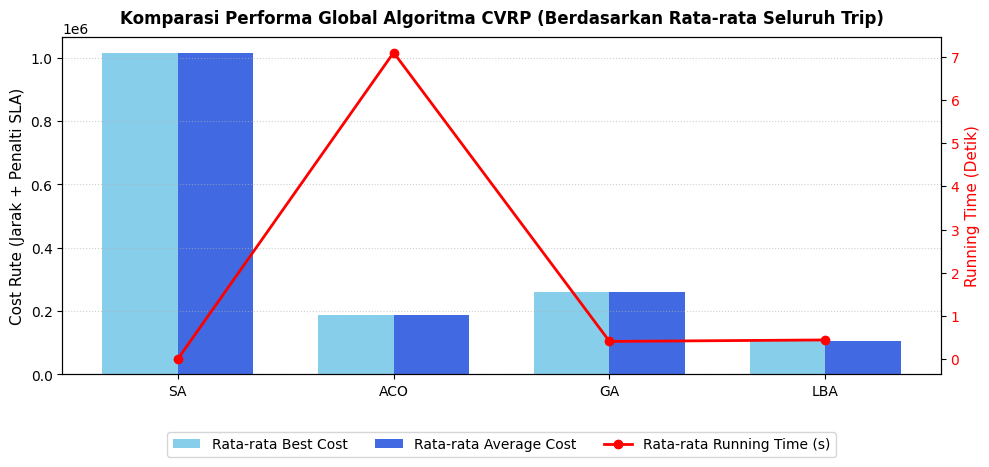

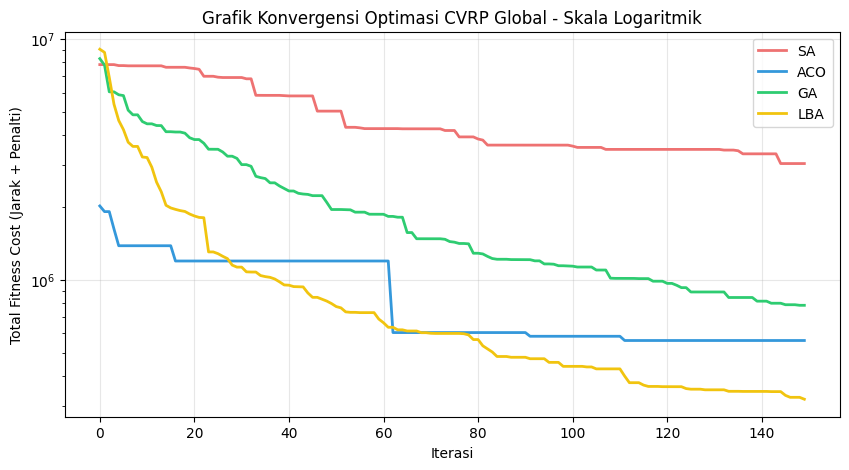

In [21]:
# --- BLOK 4: METRICS VISUALIZATION (MATPLOTLIB - CVRP SINKRON) ---
%matplotlib inline

algos = ['SA', 'ACO', 'GA', 'LBA']

# Perbaikan ekstraksi data: filter baris berdasarkan nama algoritma, lalu hitung rata-ratanya
avg_best_costs = [df_hasil[df_hasil['Algoritma'] == alg]['Best_Cost'].mean() for alg in algos]
avg_avg_costs = [df_hasil[df_hasil['Algoritma'] == alg]['Avg_Cost'].mean() for alg in algos]
avg_exec_times = [df_hasil[df_hasil['Algoritma'] == alg]['Time(s)'].mean() for alg in algos]

x = np.arange(len(algos))
width = 0.35
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Bar Chart untuk performa kualitas rute (Fitness Cost)
bar1 = ax1.bar(x - width/2, avg_best_costs, width, label='Rata-rata Best Cost', color='skyblue')
bar2 = ax1.bar(x + width/2, avg_avg_costs, width, label='Rata-rata Average Cost', color='royalblue')
ax1.set_ylabel('Cost Rute (Jarak + Penalti SLA)', color='black', fontsize=11)
ax1.set_xticks(x)
ax1.set_xticklabels(algos)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

# Plot Line Chart menggunakan sumbu Y sekunder (Kanan) untuk mengukur Running Time
ax2 = ax1.twinx()
line = ax2.plot(x, avg_exec_times, color='red', marker='o', linewidth=2, label='Rata-rata Running Time (s)')
ax2.set_ylabel('Running Time (Detik)', color='red', fontsize=11)
ax2.tick_params(axis='y', labelcolor='red')

# Penggabungan legenda dari kedua sumbu grafik agar rapi di bawah area plot
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3)

plt.title('Komparasi Performa Global Algoritma CVRP (Berdasarkan Rata-rata Seluruh Trip)', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('Grafik_Komparasi_Algoritma.png', dpi=300)
plt.show()

# --- GRAFIK KEDUA: LINTASAN KONVERGENSI ---
plt.figure(figsize=(10, 5))
for alg, color in [('SA','#ee7272'), ('ACO','#3498db'), ('GA','#2ecc71'), ('LBA','#f1c40f')]:
    plt.plot(hists[alg], label=alg, color=color, linewidth=2)
    
plt.yscale('log') # Skala logaritmik sangat bagus untuk menonjolkan akselerasi penurunan cost
plt.title('Grafik Konvergensi Optimasi CVRP Global - Skala Logaritmik')
plt.xlabel('Iterasi')
plt.ylabel('Total Fitness Cost (Jarak + Penalti)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('Grafik_Konvergensi_Algoritma.png', dpi=300)
plt.show()

# Map Dashboard

In [23]:
# --- BLOK 5: GEOSPATIAL MAP INTERACTIVE DASHBOARD (FOLIUM - DINAMIS) ---
m = folium.Map(location=[DC_JUANDA[0], DC_JUANDA[1]], zoom_start=12, tiles='CartoDB positron')
tc = {0: "#ee7272", 1: "#f2dc60", 2: "#51e356", 3: "#9b59b6", 4: "#34495e"} # Ditambah variasi warna jika trip > 3

folium.Marker(location=DC_JUANDA, popup='<b>Depot DC Juanda</b>', icon=folium.Icon(color='blue', icon='home')).add_to(m)

# Cari tahu berapa jumlah trip terbanyak yang dihasilkan di antara semua algo untuk batas filter HTML
max_trips_found = max(len(trips) for trips in all_routes.values())

for alg, trips in all_routes.items():
    lg = folium.FeatureGroup(name=f"{alg}", show=(alg=='LBA'))
    for idx, t in enumerate(trips):
        folium.PolyLine(t['geom'], color=tc.get(idx,'#2980b9'), weight=5, opacity=0.85, 
                        tooltip=f"{alg} - Trip {idx+1}", className=f"route-line line-algo-{alg} line-trip-{idx}").add_to(lg)
        for p in t['p']:
            icon_c = '#e74c3c' if p['p'] else '#f39c12'
            w_str = (datetime.strptime("08:00","%H:%M")+timedelta(minutes=p['w'])).strftime("%H:%M")
            
            folium.Marker(
                p['c'], 
                icon=folium.DivIcon(html=f'<div class="custom-marker algo-{alg} trip-{idx} {"type-pe" if p["p"] else "type-reg"}" style="background:{icon_c};color:white;border-radius:50%;width:22px;height:22px;display:flex;justify-content:center;align-items:center;font-weight:bold;font-size:10px;border:2px solid white;box-shadow:0px 4px 10px rgba(0,0,0,0.25);">{p["u"]}</div>'),
                popup=f"<b>{alg} Trip {idx+1}</b><br>Urutan: {p['u']}<br>Estimasi Tiba: {w_str} WIB"
            ).add_to(lg)
    lg.add_to(m)

folium.LayerControl(position='topright', collapsed=False).add_to(m)

# 1. SUNTIKAN UI CSS HEADER HTML
header_html = f'''
<div style="position:fixed; top:0; left:0; width:100%; height:65px; background:linear-gradient(135deg, #0f172a 0%, #1e3a8a 100%); color:#f1f5f9; z-index:9999; display:flex; align-items:center; padding-left:25px; font-family:'Segoe UI', Roboto, Arial; box-shadow:0 4px 20px rgba(0,0,0,0.3); border-bottom: 2px solid #00d2ff;">
    <h2 style="margin:0; font-size:20px; font-weight:600; letter-spacing:0.8px;">DASHBOARD RUTE PENGANTARAN PAKET (CVRP MODE)</h2>
</div>
<style>
    .leaflet-top.leaflet-right {{ margin-top: 85px !important; margin-right: 30px !important; }}
    .leaflet-control-layers {{ background: rgba(15, 23, 42, 0.88) !important; backdrop-filter: blur(10px) !important; border: 1px solid rgba(0, 210, 255, 0.3) !important; border-radius: 16px !important; color: #f1f5f9 !important; padding: 20px !important; font-size: 13px !important; width: 255px !important; }}
    .leaflet-control-layers-base {{ display: none !important; }}
    .leaflet-control-layers-overlays::before {{ content: "METODE" !important; display: block !important; font-weight: bold !important; color: #00d2ff !important; font-size: 13px !important; margin-bottom: 8px !important; border-bottom: 1px solid rgba(0, 210, 255, 0.25) !important; padding-bottom: 4px !important; }}
    .leaflet-control-layers-overlays label {{ margin-bottom: 8px !important; display: flex !important; align-items: center !important; color: #ffffff !important; }}
</style>
'''

# 2. GENERATE CHECKBOX TRIP SECARA DINAMIS BERDASARKAN HASIL ALGO
trip_checkboxes_html = ""
for t_idx in range(max_trips_found):
    trip_checkboxes_html += f'<div style="margin-bottom:8px;"><input type="checkbox" id="t{t_idx}" checked onchange="up()" style="cursor:pointer;"> <label for="t{t_idx}" style="color:#ffffff;font-weight:600;cursor:pointer;margin-left:6px;">Trip {t_idx+1}</label></div>\n'

filter_html = f'''
<div class="modern-dashboard-panel" style="position:fixed; bottom:35px; right:30px; width:255px; background:rgba(15, 23, 42, 0.88); backdrop-filter:blur(10px); border-radius:16px; padding:20px; z-index:9999; font-family:'Segoe UI', Roboto, Arial; box-shadow:0 12px 36px rgba(0,0,0,0.3); border:1px solid rgba(0, 210, 255, 0.3); color:#f1f5f9; box-sizing: border-box;">
    <b style="color:#00d2ff; font-size:13px; display:block; margin-bottom:8px; letter-spacing:0.5px;">TRIP CONTROL</b>
    <hr style="border:0; border-top:1px solid rgba(0, 210, 255, 0.25); margin:6px 0 12px 0;">
    {trip_checkboxes_html}
    <b style="color:#00d2ff; font-size:13px; display:block; margin-top:14px; margin-bottom:8px; letter-spacing:0.5px;">KLASIFIKASI PAKET</b>
    <hr style="border:0; border-top:1px solid rgba(0, 210, 255, 0.25); margin:6px 0 12px 0;">
    <div style="margin-bottom:8px;"><input type="checkbox" id="reg" checked onchange="up()" style="cursor:pointer;"> <label for="reg" style="cursor:pointer;margin-left:6px;color:#ffffff;">Paket Reguler <span style="color:#f39c12">●</span></label></div>
    <div><input type="checkbox" id="pe" checked onchange="up()" style="cursor:pointer;"> <label for="pe" style="cursor:pointer;margin-left:6px;color:#ffffff;">Paket Ekspres <span style="color:#e74c3c">●</span></label></div>
</div>

<script>
function up(){{
    // Membaca status seluruh checkbox trip yang ada secara dinamis
    var maxTrips = {max_trips_found};
    var tripStatus = [];
    for(var t=0; t<maxTrips; t++){{
        var el = document.getElementById("t"+t);
        tripStatus.push(el ? el.checked : false);
    }}
    
    var rg = document.getElementById("reg").checked;
    var pe = document.getElementById("pe").checked;
    
    // Filter untuk Marker Lokasi Konsumen
    document.querySelectorAll(".custom-marker").forEach(m => {{
        var currentTripIdx = -1;
        for(var t=0; t<maxTrips; t++){{
            if(m.classList.contains("trip-"+t)){{ currentTripIdx = t; break; }}
        }}
        
        var isTripVisible = currentTripIdx !== -1 ? tripStatus[currentTripIdx] : false;
        var isTypeVisible = (m.classList.contains("type-reg") && rg) || (m.classList.contains("type-pe") && pe);
        
        if(m.parentNode) m.parentNode.style.display = (isTripVisible && isTypeVisible) ? "block" : "none";
    }});
    
    // Filter untuk Garis Polylines Jalur Raya OSRM
    document.querySelectorAll(".route-line").forEach(line => {{
        var currentLineTripIdx = -1;
        for(var t=0; t<maxTrips; t++){{
            if(line.classList.contains("line-trip-"+t)){{ currentLineTripIdx = t; break; }}
        }}
        var showLine = currentLineTripIdx !== -1 ? tripStatus[currentLineTripIdx] : false;
        line.style.display = showLine ? "block" : "none";
    }});
}}

var obs = new MutationObserver(up);
obs.observe(document.body, {{ childList: true, subtree: true }});
setTimeout(up, 600);
</script>
'''

m.get_root().html.add_child(folium.Element(header_html + filter_html))
m.save('Dashboard_Rute_EAS_Final.html')
print("[OUTPUT] File dashboard geospatial sukses diperbarui: 'Dashboard_Rute_EAS_Final.html'")
m 

[OUTPUT] File dashboard geospatial sukses diperbarui: 'Dashboard_Rute_EAS_Final.html'
